# Installation and importing libraries

In [ ]:
!pip install abtem
!pip install gpaw

INFO: pip is looking at multiple versions of distributed to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 145.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.1 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.1
    Uninstalling dask-2026.1.1:
      Successfully uninstalled dask-

In [ ]:
import ase
from ase.io import read
from ase.build import make_supercell
from ase.data import chemical_symbols
from ase import Atoms
from collections import defaultdict

import abtem
from abtem.scan import CustomScan
from abtem.scan import ScanAxis

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch, time

import tifffile
import os

In [ ]:
import cupy as cp

# Helper functions

In [ ]:
def plot_structure(atoms, figsize = (6,6),plane="xy"):
  symbols = atoms.get_chemical_symbols()
  colors = []
  for s in symbols:
      if s == 'W':
          colors.append('blue')
      elif s == 'S':
          colors.append('yellow')


  fig, ax = abtem.show_atoms(
      atoms,
      plane = plane,
      color=colors,
      scale=0.5,
      figsize=figsize,
      legend=False)


  for coll in ax.collections:
      coll.set_edgecolor('black')
      coll.set_linewidth(0.6)


  legend_elements = [
      Line2D([0], [0], marker='o', linestyle='none',
             markerfacecolor='blue', markeredgecolor='black',
             markersize=8, label='W'),

      Line2D([0], [0], marker='o', linestyle='none',
             markerfacecolor='yellow', markeredgecolor='black',
             markersize=8, label='S'),


  ]

  ax.legend(handles=legend_elements, loc='upper right')
  return fig,ax

In [ ]:
def print_measurement_attributes(m):
    attrs = [
        "array",
        "axes_metadata",
        "azimuthal_offset",
        "azimuthal_sampling",
        "base_axes_metadata",
        "base_dims",
        "base_shape",
        "device",
        "dtype",
        "ensemble_axes_metadata",
        "ensemble_dims",
        "ensemble_shape",
        "is_complex",
        "is_lazy",
        "metadata",
        "outer_angle",
        "radial_offset",
        "radial_sampling",
        "shape",
    ]

    for attr in attrs:
        if hasattr(m, attr):
            val = getattr(m, attr)
            if hasattr(val, "shape"):
                print(f"{attr:25s}: array with shape {val.shape}")
            else:
                print(f"{attr:25s}: {val}")
        else:
            print(f"{attr:25s}: <not present>")

In [ ]:
def set_up_simulation_parameters(atoms, n_phonons, sampling, energy, semiangle_cutoff, Cs, defocus):
  frozen_phonons = abtem.FrozenPhonons(atoms, n_phonons, sigmas=0.1)
  probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_cutoff, Cs=Cs, defocus=defocus)
  potential = abtem.Potential(frozen_phonons, sampling=sampling)
  probe.grid.match(potential)

  print(f"defocus = {probe.aberrations.defocus} Å")
  print(f"FWHM = {probe.profiles().width().compute()} Å")

  detector = abtem.FlexibleAnnularDetector()

  return potential, detector, probe

In [ ]:
def save_raw_polar_measurement(measurement, scan, path, name):
  data = measurement.array
  metadata = {
    "scan shape": scan.shape,
    "radial_sampling": measurement.radial_sampling,
    "azimuthal_sampling": measurement.azimuthal_sampling,
    "radial_offset": measurement.radial_offset,
    "azimuthal_offset": measurement.azimuthal_offset,
    "metadata": measurement.metadata}
  filename = path + name + ".npz"
  np.savez(
    filename,
    data=data,
    metadata=metadata)

In [ ]:
def get_haadf(measurements, interp, filter, path, name, add_noise = False, dose=5e2):
  interpolated_measurements = measurements.interpolate(interp)
  filtered_measurements = interpolated_measurements.gaussian_filter(filter)
  if add_noise:
    noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=dose)
  else:
    dose = "no_noise"
    noisy_measurements = filtered_measurements
  image_to_save = noisy_measurements[2].array

  plt.imshow(image_to_save, cmap='gray')
  plt.show()

  name = f"{name}_interp_{interp}_dose_{dose}.tif"
  path = path + name
  tifffile.imwrite(path, image_to_save)

In [ ]:
def get_distorted_positions(grid_scan, sigma_flag, sigma_skip):
  pos_grid = grid_scan.get_positions()   # (N, 2), Å
  ny, nx = grid_scan.shape
  rng = np.random.default_rng(42)

  pos_dist = pos_grid.reshape(ny, nx, 2).copy()

  # shift value per row
  flags = rng.normal(scale=sigma_flag, size=ny)
  skips = rng.normal(scale=sigma_skip, size=ny)

  # accumulated skip
  skip_cumsum = np.cumsum(skips)

  for j in range(ny):
      pos_dist[j, :, 1] += flags[j]
      pos_dist[j, :, 0] += skip_cumsum[j]

  pos_dist = pos_dist.reshape(-1, 2)

  return pos_dist

In [ ]:
import numpy as np
import abtem
from abtem.core.axes import ScanAxis


def convert_distorted_scan(ns_measurement, gt_measurement, grid_scan):
    """
    Convert a distorted scan measurement to a regular GridScan layout
    with correct real-space axes in Angstrom.
    """

    # --- scan geometry ---
    ny, nx = grid_scan.shape          # number of scan points
    ns_arr_grid = ns_measurement.array.reshape(ny, nx, *ns_measurement.array.shape[1:])
    ns_measurement_corr = gt_measurement.copy()
    ns_measurement_corr.array = ns_arr_grid

    return ns_measurement_corr


# Creating structure

## Opening structure

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

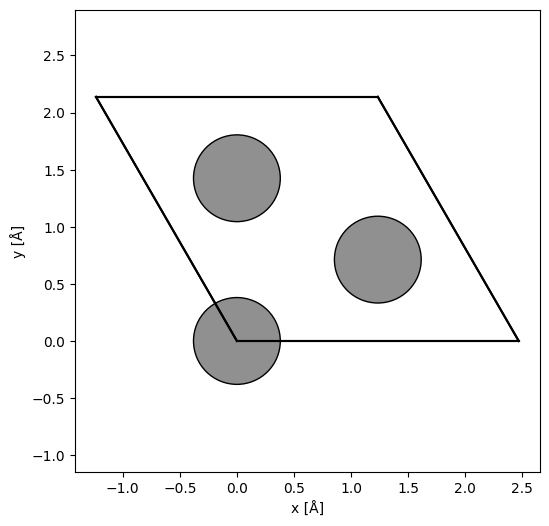

In [ ]:
atoms = read("/content/sample_data/C_mp-48_primitive.cif")

abtem.show_atoms(atoms, scale=0.5, figsize=(6,6))

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

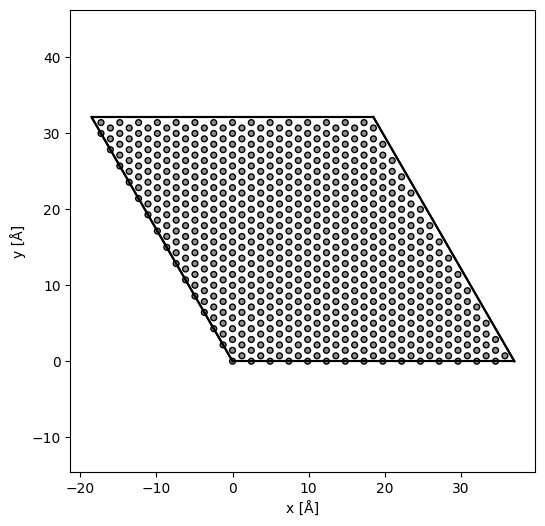

In [ ]:
atoms_sc = atoms.repeat((15, 15, 1))
abtem.show_atoms(atoms_sc, scale=0.5, figsize=(6,6))

a·b = -1.4614745572480522e-13


(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

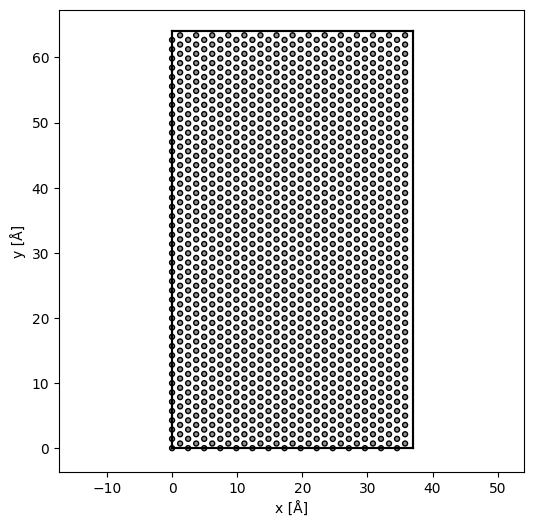

In [ ]:
P = np.array([
    [ 1,  1, 0],
    [-1,  1, 0],
    [ 0,  0, 1]
])
atoms_ortho = make_supercell(atoms_sc, P)

atoms_ortho.center(vacuum=2, axis=2)

a, b, c = atoms_ortho.cell
print("a·b =", np.dot(a, b))

atoms_ortho.rotate(-60, 'z', rotate_cell=True)
abtem.show_atoms(atoms_ortho, scale=0.5, figsize=(6,6))

## Creating vacancies

In [ ]:
import numpy as np


def create_random_C_vacancies(
    atoms,
    n_vacancies=5,
    ws_cutoff=2.6,
    seed=42
):

    atoms_defect = atoms.copy()

    symbols = np.array(atoms.get_chemical_symbols())

    # indices of all C atoms
    C_indices = np.where(symbols == "C")[0]

    if n_vacancies > len(C_indices):
        raise ValueError(
            f"Requested {n_vacancies} vacancies, "
            f"but structure contains only {len(C_indices)} C atoms."
        )

    rng = np.random.default_rng(seed)

    # randomly select C atoms
    selected_C = rng.choice(
        C_indices,
        size=n_vacancies,
        replace=False
    )

    remove_indices = set()
    vacancy_positions = []

    for C_idx in selected_C:

        C_position = atoms.positions[C_idx]

        vacancy_positions.append(C_position[:2].copy())

        # Remove C itself
        remove_indices.add(C_idx)


    # Important: remove simultaneously
    # Convert set to a list before deletion
    del atoms_defect[list(remove_indices)]

    return atoms_defect, np.array(vacancy_positions)

(<Figure size 2000x2000 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

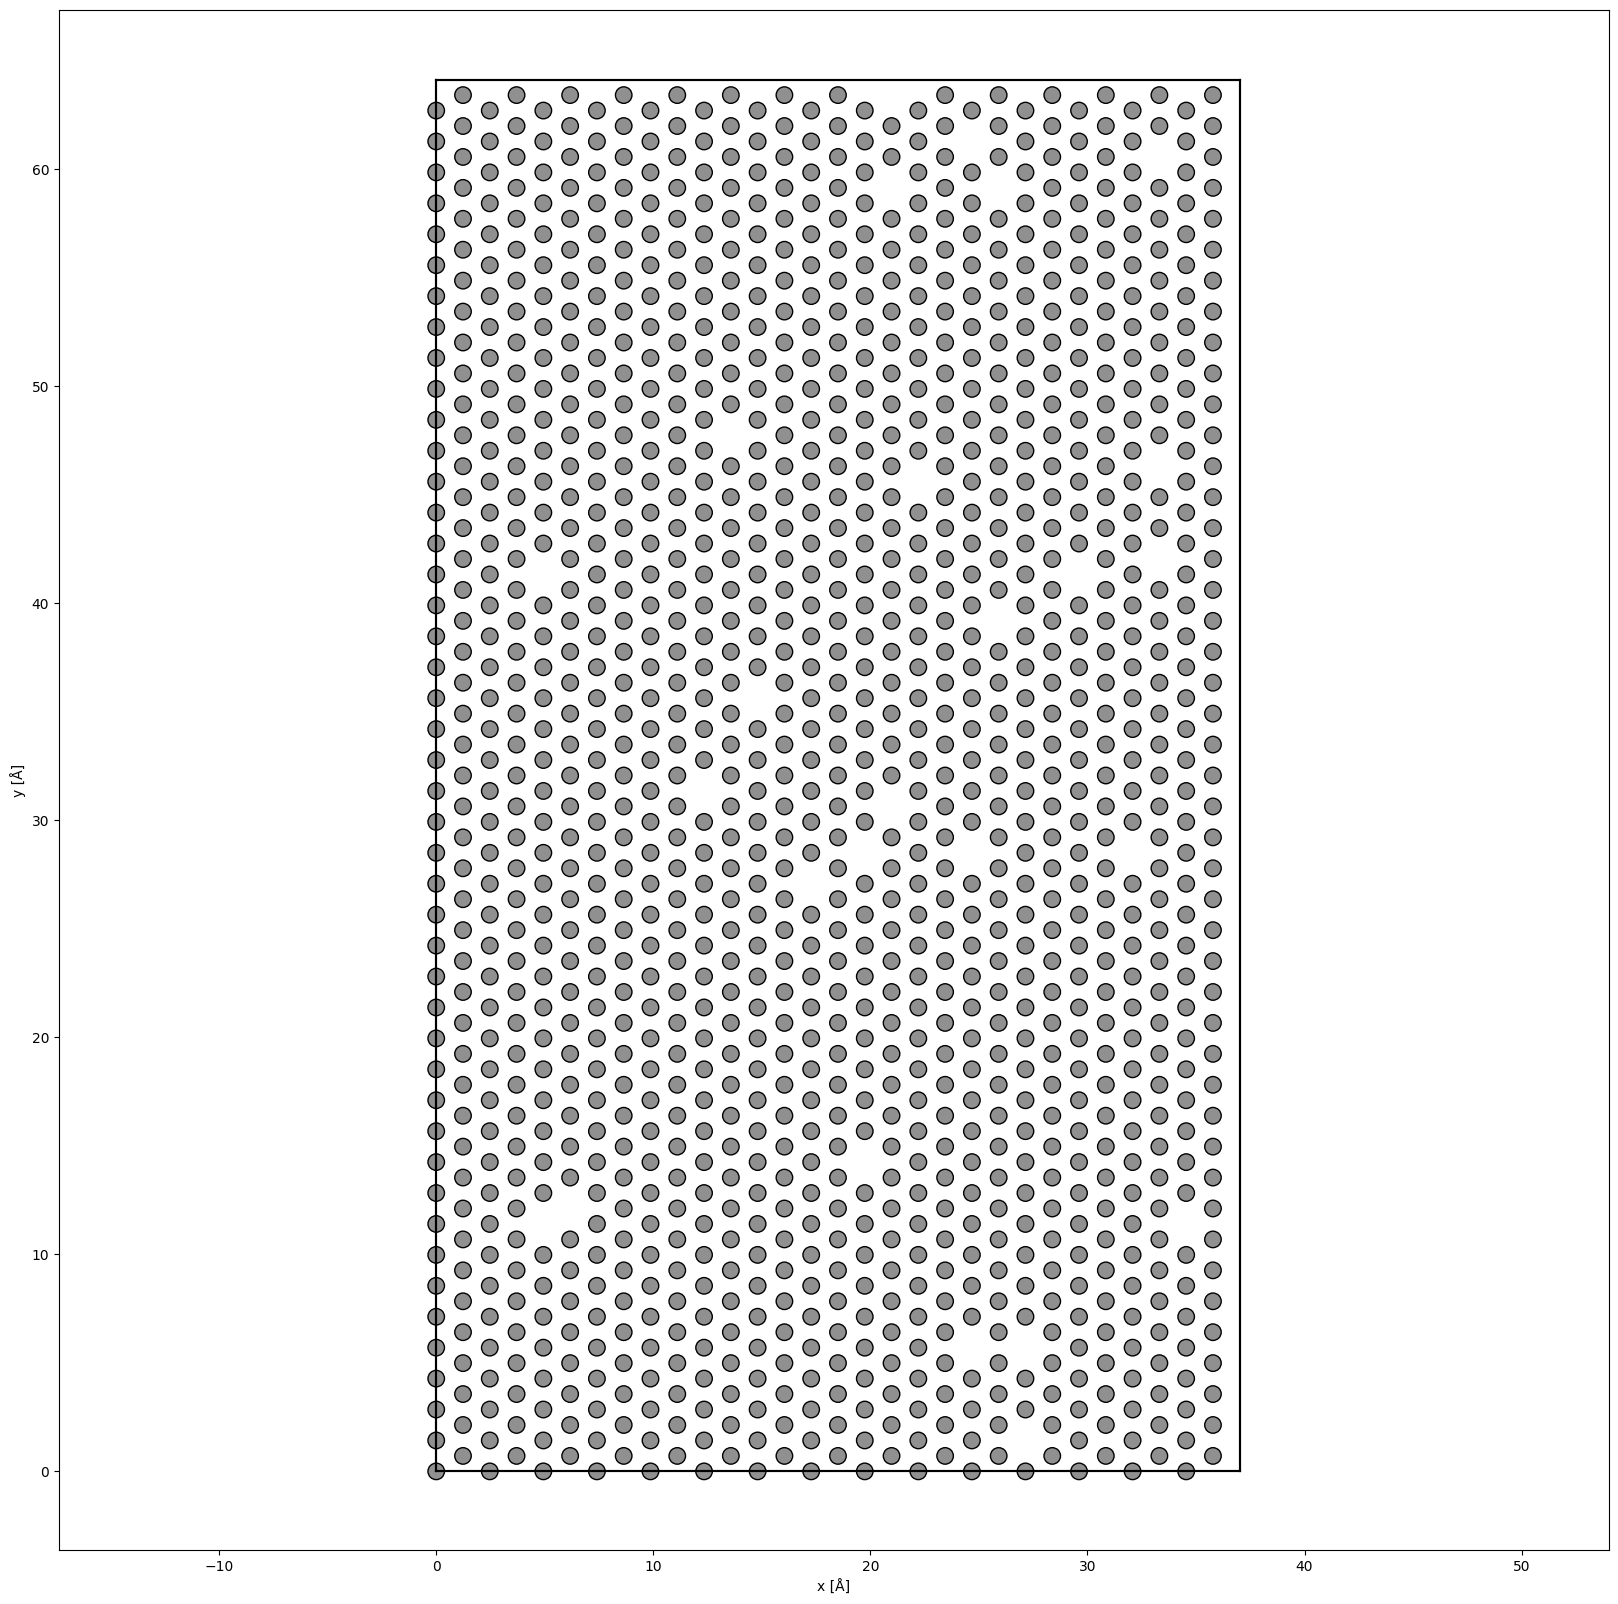

In [ ]:
atoms_defect, vacancy_positions = create_random_C_vacancies(
    atoms_ortho,
    n_vacancies=40,
    ws_cutoff=2.6,
    seed=56
)
abtem.show_atoms(atoms_defect, scale=0.5, figsize=(20,20))

# Ground truth simulation

In [ ]:
ATOMS = atoms_defect
N_PHONONS = 8
SAMPLING = 0.05
ENERGY = 80e3
CUTOFF_ANGLE = 30
CS = 10e4
DEFOCUS ="scherzer"
PATH = "/content/sample_data/graphene_vacancies/"
os.makedirs(PATH, exist_ok=True)
FILENAME = "graphene-ground_truth"

In [ ]:
abtem.config.set({"device": "gpu", "fft": "fftw"})

In [ ]:
potential, detector, probe = set_up_simulation_parameters(ATOMS, N_PHONONS, SAMPLING, ENERGY, CUTOFF_ANGLE, CS, DEFOCUS)

defocus = 79.14274499114904 Å
FWHM = 0.6993550062179565 Å


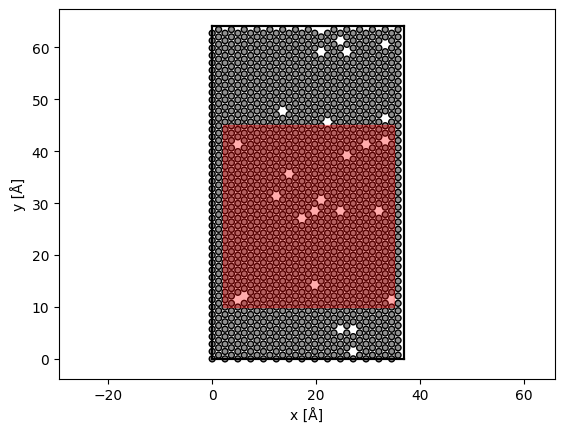

In [ ]:
Lx, Ly, Lz = ATOMS.cell.lengths()

grid_scan = abtem.GridScan(
    start=(2,10),
    end=(35,45),
    sampling=probe.aperture.nyquist_sampling,
    fractional=False,
    potential=potential,
)

fig, ax = abtem.show_atoms(ATOMS)

grid_scan.add_to_plot(ax)

In [ ]:
gt_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)
print_measurement_attributes(gt_measurement)

array                    : array with shape (95, 101, 277, 1)
axes_metadata            : type        label                             coordinates
----------  --------------------------------  ---------------------
ScanAxis    x [Å]                             2.00 2.35 ... 34.65
ScanAxis    y [Å]                             10.00 10.35 ... 44.65
LinearAxis  Radial scattering angle [mrad]    0.00 1.00 ... 276.00
LinearAxis  Azimuthal scattering angle [rad]  0.00
azimuthal_offset         : 0.0
azimuthal_sampling       : 6.283185307179586
base_axes_metadata       : [<abtem.core.axes.LinearAxis object at 0x78e340040870>, <abtem.core.axes.LinearAxis object at 0x78e340040af0>]
base_dims                : 2
base_shape               : (277, 1)
device                   : cpu
dtype                    : array with shape ()
ensemble_axes_metadata   : [<abtem.core.axes.ScanAxis object at 0x78e334690470>, <abtem.core.axes.ScanAxis object at 0x78e334690520>]
ensemble_dims            : 2
ensemble_shap

In [ ]:
torch.cuda.synchronize()
start = time.perf_counter()
gt_measurement.compute()
torch.cuda.synchronize()
print(f"GPU time: {time.perf_counter() - start:.3f} s")

tasks:   0%|          | 3/2357 [00:07<1:31:51,  2.34s/it]

GPU time: 401.347 s


In [ ]:
save_raw_polar_measurement(gt_measurement, grid_scan, PATH, FILENAME)

In [ ]:
bf_measurement = gt_measurement.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = gt_measurement.integrate_radial(5, 25)
haadf_measurement = gt_measurement.integrate_radial(86, 190)

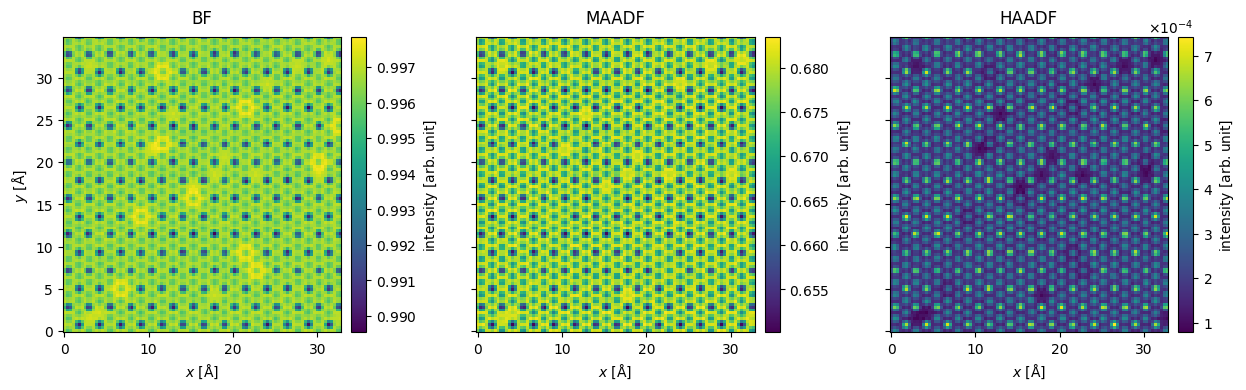

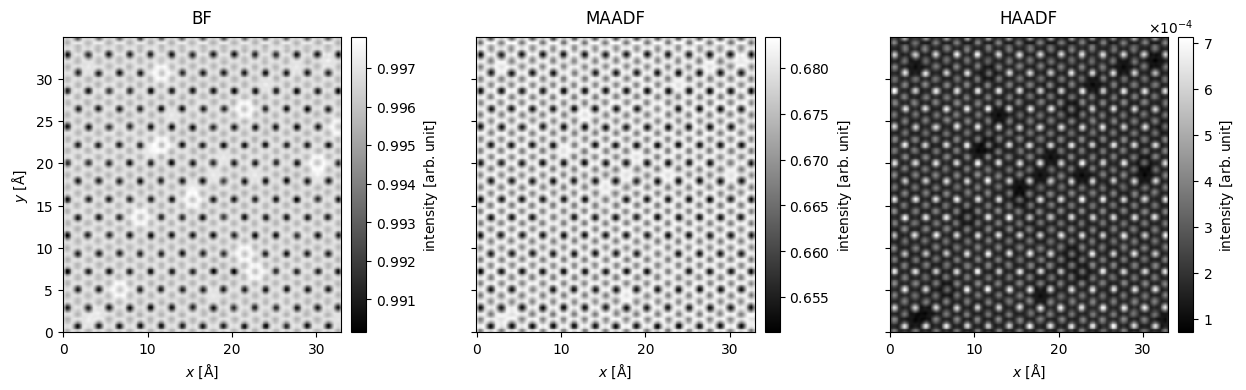

In [ ]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement, haadf_measurement], ("BF", "MAADF", "HAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True
);

interpolated_measurements = measurements.interpolate(0.1)
filtered_measurements = interpolated_measurements.gaussian_filter(0.1)
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap = "gray"
);

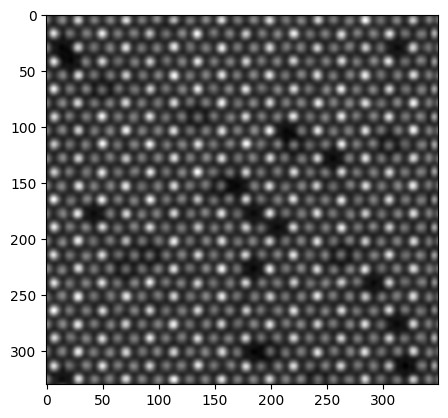

In [ ]:
get_haadf(filtered_measurements, 0.1, 0.1, PATH, FILENAME, add_noise=False)

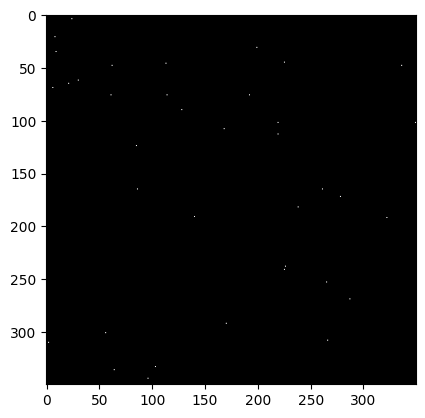

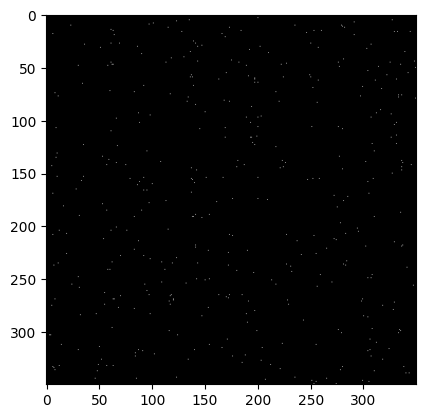

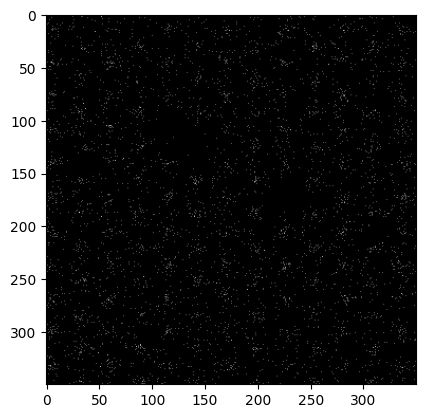

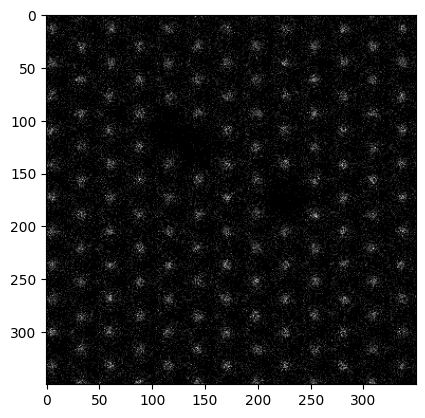

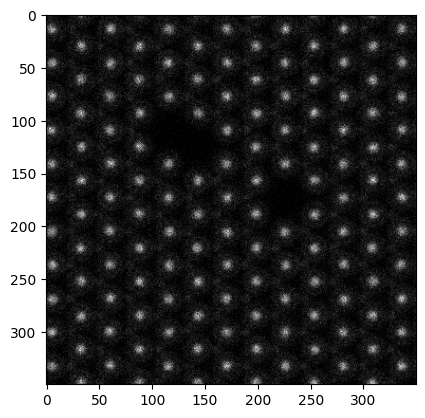

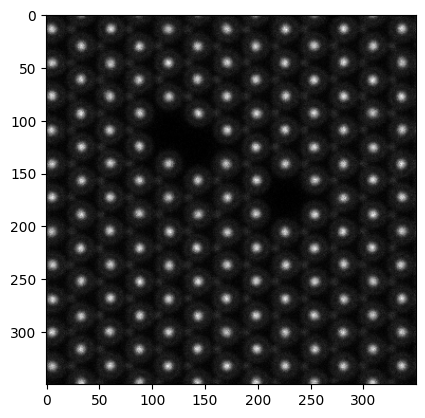

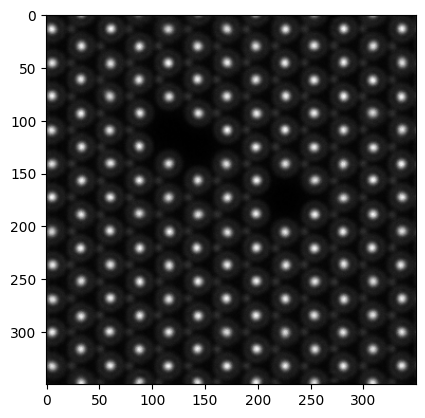

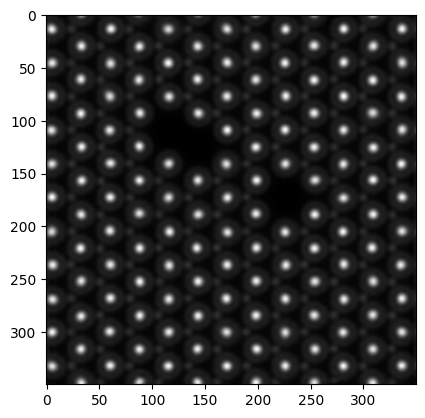

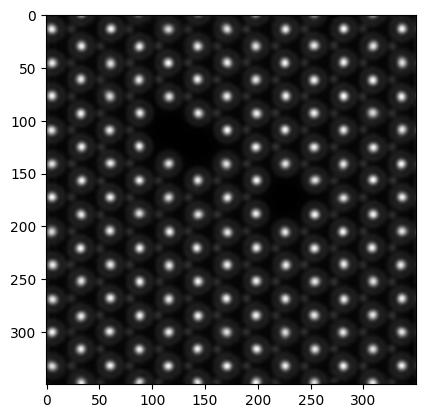

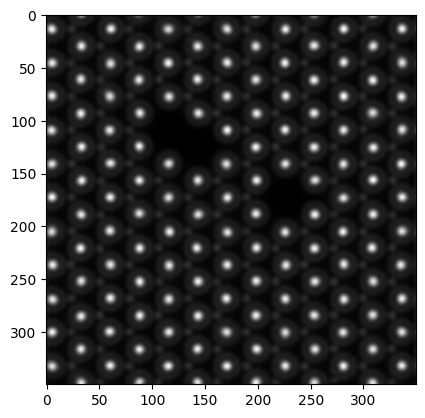

In [ ]:
interp_values = [0.1]
dose_values = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]
for interp in interp_values:
  for dose in dose_values:
    get_haadf(measurements, interp, 0.1, PATH, FILENAME, add_noise=True, dose=dose)

# Adding scanning distortions

In [ ]:
SIGMA_FLAG = np.square(32e-2)   # Å
SIGMA_SKIP = np.square(14.5e-2)   # Å
FILENAME = "graphene-jittered"

In [ ]:
pos_dist = get_distorted_positions(grid_scan, SIGMA_FLAG, SIGMA_SKIP)

In [ ]:
scan_distorted = CustomScan(
    pos_dist,          # (N, 2)
    grid_scan.shape    # (ny, nx)
)

In [ ]:
ns_measurement = probe.scan(potential, scan=scan_distorted, detectors=detector)

In [ ]:
torch.cuda.synchronize()
start = time.perf_counter()
ns_measurement.compute()
torch.cuda.synchronize()
print(f"GPU time: {time.perf_counter() - start:.3f} s")

tasks:   0%|          | 4/2177 [00:00<06:25,  5.64it/s]

GPU time: 387.823 s


In [ ]:
ns_measurement_corr = convert_distorted_scan(ns_measurement, gt_measurement, grid_scan)
print_measurement_attributes(ns_measurement_corr)

array                    : array with shape (95, 101, 277, 1)
axes_metadata            : type        label                             coordinates
----------  --------------------------------  ---------------------
ScanAxis    x [Å]                             2.00 2.35 ... 34.65
ScanAxis    y [Å]                             10.00 10.35 ... 44.65
LinearAxis  Radial scattering angle [mrad]    0.00 1.00 ... 276.00
LinearAxis  Azimuthal scattering angle [rad]  0.00
azimuthal_offset         : 0.0
azimuthal_sampling       : 6.283185307179586
base_axes_metadata       : [<abtem.core.axes.LinearAxis object at 0x78e3340b8af0>, <abtem.core.axes.LinearAxis object at 0x78e3340b9e50>]
base_dims                : 2
base_shape               : (277, 1)
device                   : cpu
dtype                    : array with shape ()
ensemble_axes_metadata   : [<abtem.core.axes.ScanAxis object at 0x78e302705bd0>, <abtem.core.axes.ScanAxis object at 0x78e302693a10>]
ensemble_dims            : 2
ensemble_shap

In [ ]:
save_raw_polar_measurement(ns_measurement_corr, grid_scan, PATH, FILENAME)

In [ ]:
bf_measurement = ns_measurement_corr.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = ns_measurement_corr.integrate_radial(5, 25)
haadf_measurement = ns_measurement_corr.integrate_radial(86, 190)

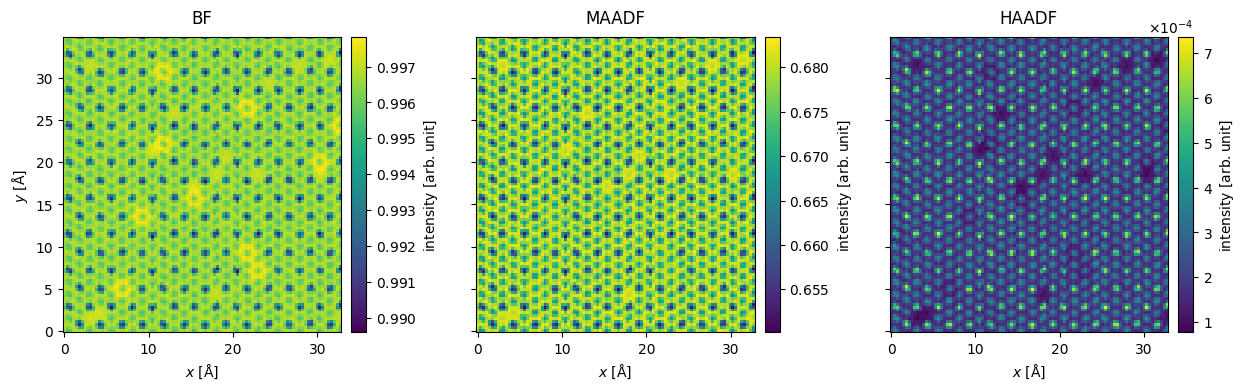

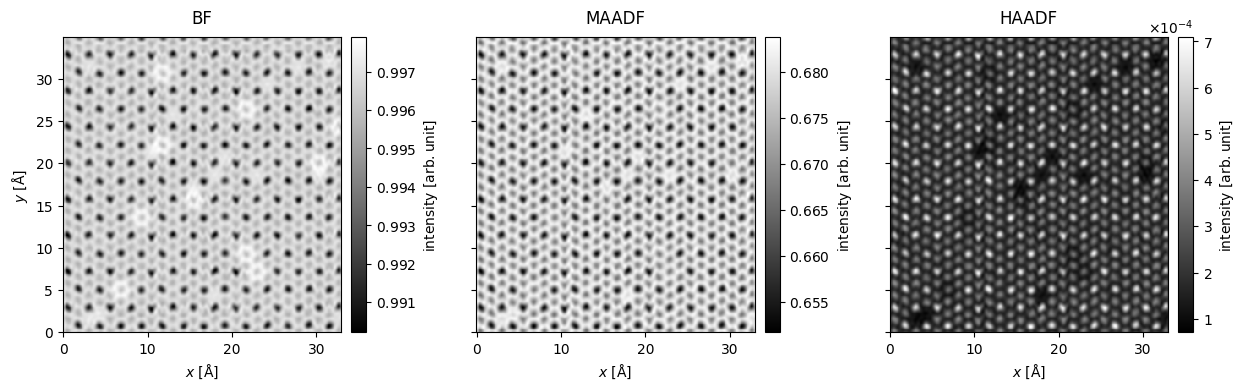

In [ ]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement, haadf_measurement], ("BF", "MAADF", "HAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True
);
interpolated_measurements = measurements.interpolate(0.1)
filtered_measurements = interpolated_measurements.gaussian_filter(0.1)
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap = "gray"
);

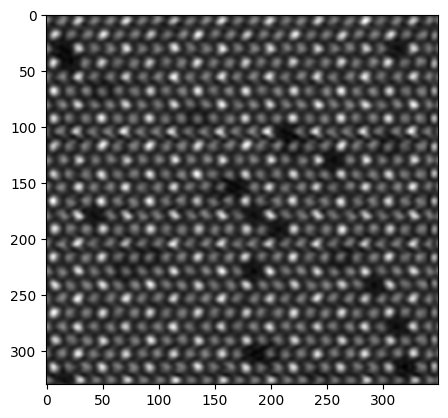

In [ ]:
get_haadf(measurements, 0.1, 0.1, PATH, FILENAME, add_noise=False)

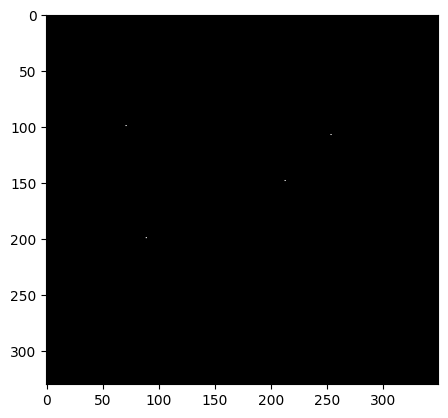

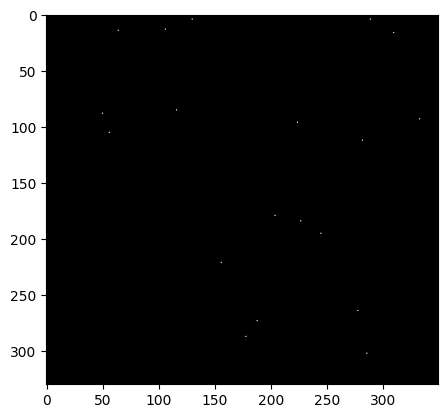

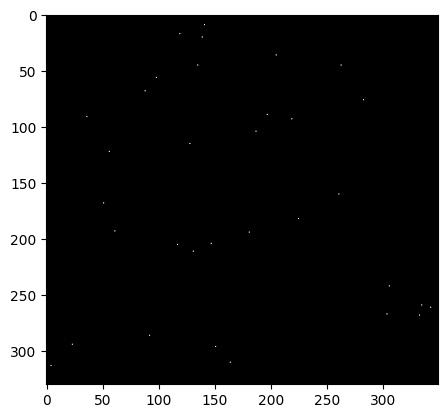

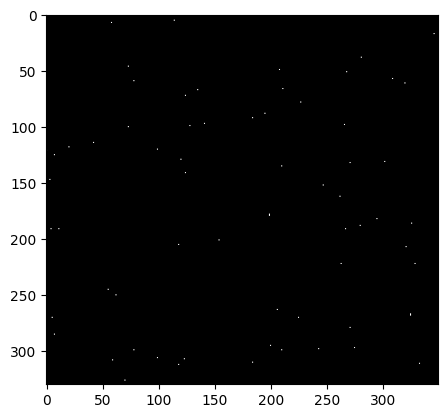

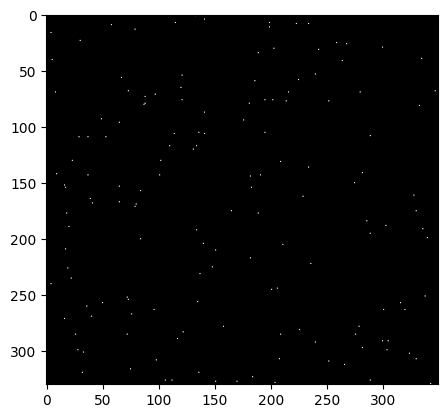

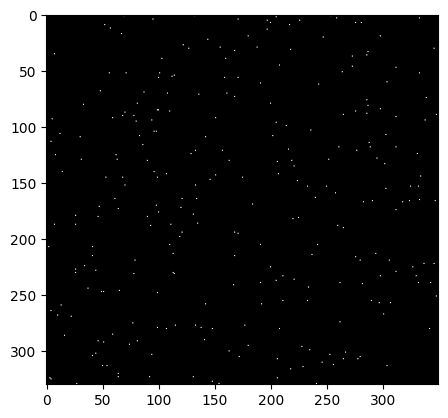

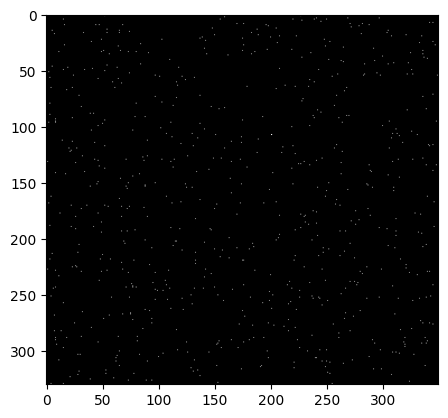

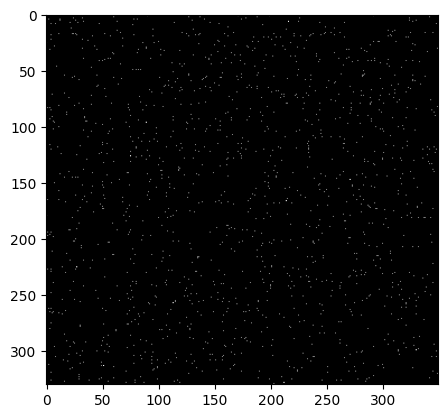

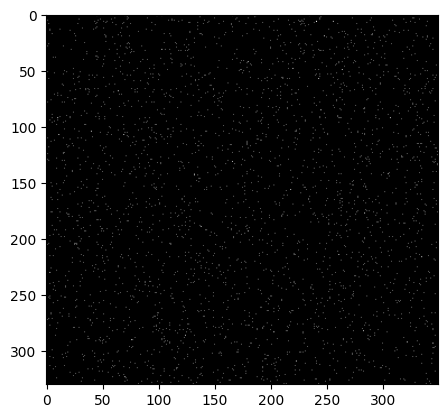

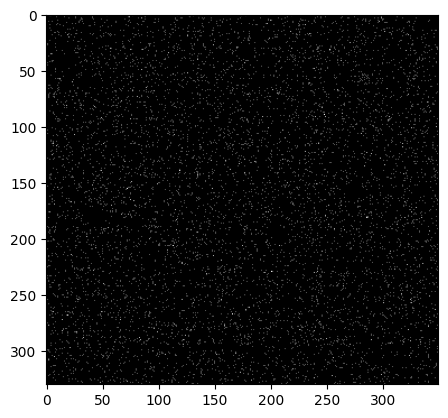

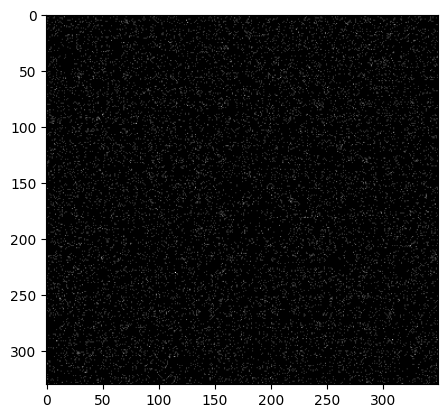

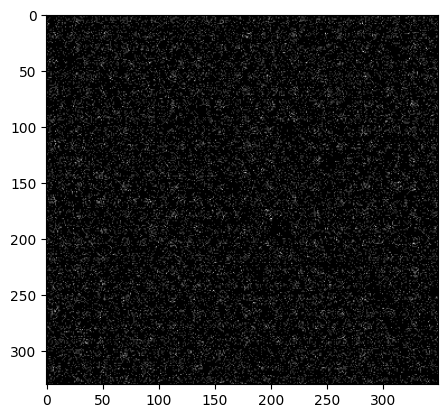

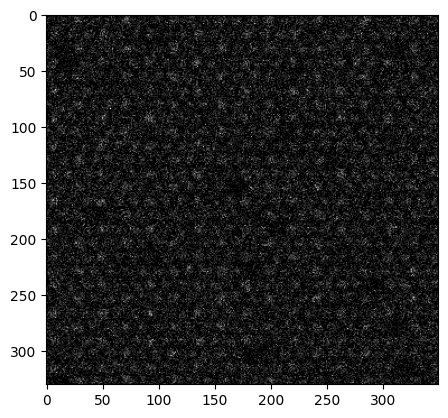

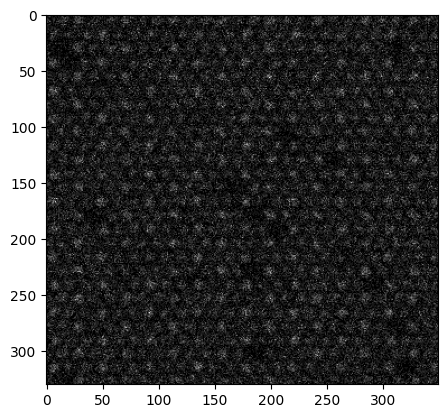

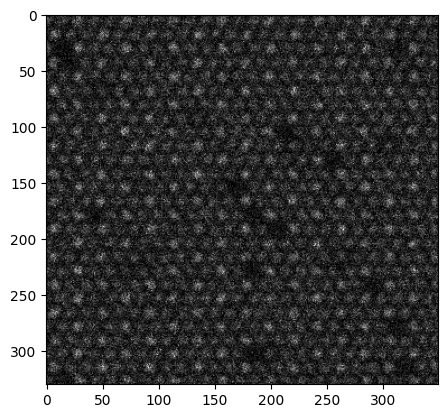

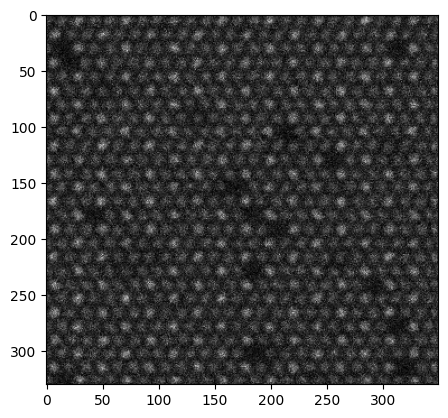

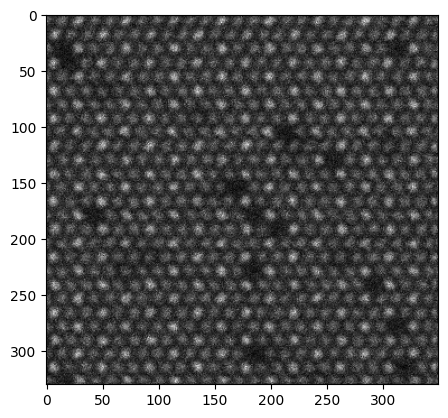

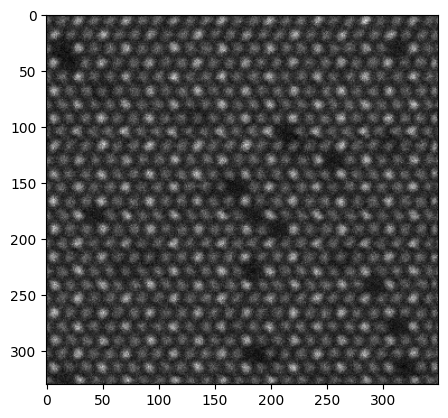

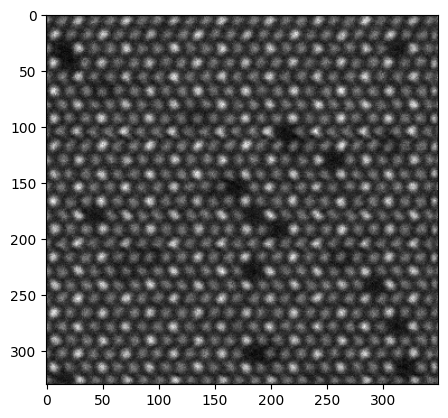

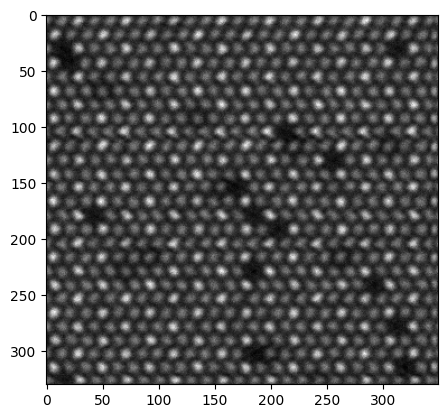

In [ ]:
interp_values = [0.1]
dose_values = [1e1, 5e1, 1e2, 2.5e2, 5e2, 1e3, 2.5e3, 5e3, 1e4, 2.5e4, 5e4, 1e5, 2.5e5, 5e5, 1e6, 2.5e6, 5e6, 1e7, 2.5e7, 5e7]
for interp in interp_values:
  for dose in dose_values:
    get_haadf(measurements, interp, 0.1, PATH, FILENAME, add_noise=True, dose=dose)